In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

[*********************100%***********************]  1 of 1 completed


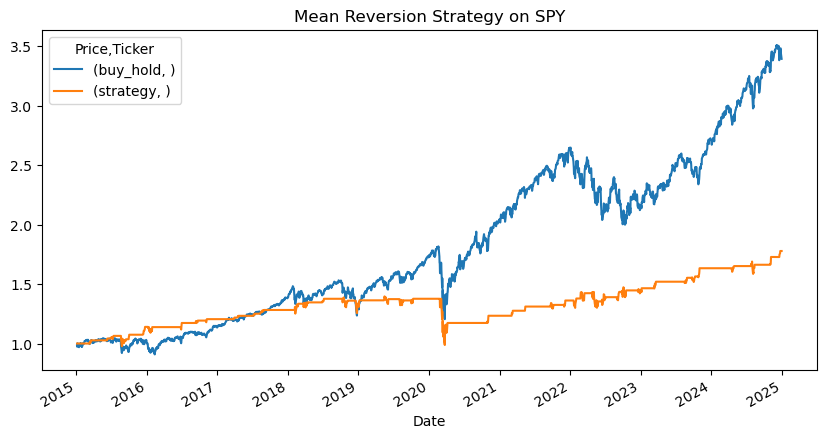

Total return: 0.7786690460760959
Sharpe ratio: 0.5256433529941943
Max drawdown: -0.2929912776435928


In [8]:
ticker = "SPY"
data = yf.download(ticker, start="2015-01-01", end="2025-01-01")

# Fix MultiIndex problem
if isinstance(data.columns, pd.MultiIndex):
    close = data["Close"][ticker]
else:
    close = data["Close"]

data["return"] = close.pct_change() #percentage change

window = 20
data["ma"] = close.rolling(window).mean()
data["std"] = close.rolling(window).std()
data["zscore"] = (close - data["ma"]) / data["std"]

data["signal"] = np.nan
data.loc[data["zscore"] < -2, "signal"] = 1
data.loc[data["zscore"] > 0, "signal"] = 0

"""
First 0 is replaced with np.nan, then ffill() will fill all np.nan to the most recent value which is 1. 
fillna will fill the entries at the begining when there is no previous value.
"""
data["position"] = data["signal"].ffill().fillna(0)

"""
strategy_return calculate the percentage the strategy earned in a day
data["position"].shift(1) used the our position from yesterday
data["return"] is the percentage earned in that day
ex: day 1: 100
    day 2: 102
    return = (102 - 100)/100 = 0.02
"""
data["strategy_return"] = data["position"].shift(1) * data["return"]

"""
cumprod() - cumulative product
(1 + data["return"]).cumprod() calculate growth of your money overtime
"buy_hould" is the growth of your money if you just buy and hold the entire time.
"strategy" is the growth of your money after implementing the strategy.
"""
data["buy_hold"] = (1 + data["return"]).cumprod()
data["strategy"] = (1 + data["strategy_return"]).cumprod()


data[["buy_hold", "strategy"]].plot(figsize=(10, 5))
plt.title(f"Mean Reversion Strategy on {ticker}")
plt.show()

total_return = data["strategy"].iloc[-1] - 1
# Sharpe ratio measures return per unit of risk.
sharpe = np.sqrt(252) * data["strategy_return"].mean() / data["strategy_return"].std()
# What is the worst percentage loss from a previous peak?
max_drawdown = (data["strategy"] / data["strategy"].cummax() - 1).min()

print("Total return:", total_return)
print("Sharpe ratio:", sharpe)
print("Max drawdown:", max_drawdown)

In [7]:
data

Price,Close,High,Low,Open,Volume,return,ma,std,zscore,signal,position,strategy_return,buy_hold,strategy
Ticker,SPY,SPY,SPY,SPY,SPY,,,,,,,,,
Date,,,,,,,,,,,,,,
2015-01-02,170.124954,171.325768,169.089778,170.911698,121465900,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
2015-01-05,167.052582,169.247150,166.746174,169.081524,169632600,-0.018060,NaN,NaN,NaN,NaN,0.0,-0.000000,0.981940,1.000000
2015-01-06,165.479111,167.880714,164.684090,167.358981,209151400,-0.009419,NaN,NaN,NaN,NaN,0.0,-0.000000,0.972692,1.000000
2015-01-07,167.541183,167.880724,166.356948,166.804139,125346700,0.012461,NaN,NaN,NaN,NaN,0.0,0.000000,0.984813,1.000000
2015-01-08,170.514221,170.729546,168.932482,168.949035,147217800,0.017745,NaN,NaN,NaN,NaN,0.0,0.000000,1.002288,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,592.702087,592.741554,586.955433,587.537023,33160100,0.011115,590.998608,6.323098,0.269406,0.0,0.0,0.011115,3.483922,1.778669
2024-12-26,592.741577,593.865231,589.528182,590.927860,41219100,0.000067,591.131912,6.330711,0.254263,0.0,0.0,0.000000,3.484154,1.778669


3.072357000000011

0.018059410850205283